In [ ]:
import os, time, random, shutil, zipfile
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import confusion_matrix, classification_report

# 재현성을 위한 시드 고정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True  # 입력 크기 고정 시 속도 향상

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 작업 디렉터리
BASE_DIR = Path('/content/dogs_vs_cats')
RAW_DIR  = BASE_DIR / 'raw'
SPLIT_DIR = BASE_DIR / 'prepared_data'
for d in [BASE_DIR, RAW_DIR, SPLIT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'device: {device}  |  torch: {torch.__version__}')


device: cuda  |  torch: 2.10.0+cu128


In [ ]:
!pip install -q gdown

In [ ]:
import gdown

# ── Google Drive 공유 링크 설정 ──────────────────────────────
GDRIVE_FILE_ID = '1EkAhsqncZjS_0IqQprw1OpkzGq_urtGi'
# ─────────────────────────────────────────────────────────────

train_zip = BASE_DIR / 'train.zip'
raw_train_dir = RAW_DIR / 'train'

# 이미 다운로드된 경우 건너뜁니다
if raw_train_dir.exists():
    print('이미 raw/train 폴더가 존재합니다. 다운로드를 건너뜁니다.')
else:
    if not train_zip.exists():
        print('Google Drive에서 train.zip 다운로드 중...')
        gdown.download(
            id=GDRIVE_FILE_ID,
            output=str(train_zip),
            quiet=False
        )
    else:
        print(f'이미 다운로드된 파일을 사용합니다: {train_zip}')

    print('train.zip 압축 해제 중...')
    with zipfile.ZipFile(train_zip) as zf:
        zf.extractall(RAW_DIR)

if not raw_train_dir.exists():
    raise FileNotFoundError(
        'raw/train 폴더를 찾지 못했습니다. '
        'GDRIVE_FILE_ID가 올바른지 확인하세요.'
    )

print(f'raw image count: {len(list(raw_train_dir.glob("*.jpg"))):,}')


Google Drive에서 train.zip 다운로드 중...


Downloading...
From (original): https://drive.google.com/uc?id=1EkAhsqncZjS_0IqQprw1OpkzGq_urtGi
From (redirected): https://drive.google.com/uc?id=1EkAhsqncZjS_0IqQprw1OpkzGq_urtGi&confirm=t&uuid=919ca6f2-06c8-4d94-be6f-834e73db2f4d
To: /content/dogs_vs_cats/train.zip
100%|██████████| 570M/570M [00:04<00:00, 135MB/s]


train.zip 압축 해제 중...
raw image count: 25,000


In [ ]:
from IPython.display import display

USE_SMALL_SUBSET = True
MAX_IMAGES_PER_CLASS = 1500
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = min(2, os.cpu_count() or 2)
EPOCHS_SCRATCH = 5
EPOCHS_TRANSFER = 5
REBUILD_SPLIT = False


def prepare_dogs_vs_cats_split(
    raw_train_dir, output_dir,
    train_ratio=0.7, val_ratio=0.15, test_ratio=0.15,
    max_per_class=None, seed=42, rebuild=False
):
    if abs(train_ratio + val_ratio + test_ratio - 1.0) > 1e-9:
        raise ValueError('train/val/test 비율의 합은 1이어야 합니다.')

    if rebuild and output_dir.exists():
        shutil.rmtree(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    existing_images = list(output_dir.glob('*/*/*.jpg'))
    if existing_images:
        print('이미 준비된 split이 있으므로 재사용합니다.')
        return

    rng = random.Random(seed)

    for class_name in ['cat', 'dog']:
        files = sorted(raw_train_dir.glob(f'{class_name}.*.jpg'))
        if max_per_class is not None:
            files = files[:max_per_class]
        rng.shuffle(files)

        n_total = len(files)
        n_train = int(n_total * train_ratio)
        n_val = int(n_total * val_ratio)
        split_map = {
            'train': files[:n_train],
            'val': files[n_train:n_train + n_val],
            'test': files[n_train + n_val:]
        }

        for split_name, split_files in split_map.items():
            target_dir = output_dir / split_name / class_name
            target_dir.mkdir(parents=True, exist_ok=True)
            for src in split_files:
                shutil.copy2(src, target_dir / src.name)


def count_images_by_split(base_dir):
    rows = []
    for split_name in ['train', 'val', 'test']:
        for class_name in ['cat', 'dog']:
            rows.append({
                'split': split_name,
                'class': class_name,
                'count': len(list(
                    (base_dir / split_name / class_name).glob('*.jpg')
                ))
            })
    return pd.DataFrame(rows)

max_per_class = MAX_IMAGES_PER_CLASS if USE_SMALL_SUBSET else None
prepare_dogs_vs_cats_split(
    raw_train_dir=RAW_DIR / 'train',
    output_dir=SPLIT_DIR,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO,
    max_per_class=max_per_class,
    seed=SEED,
    rebuild=REBUILD_SPLIT
)

count_df = count_images_by_split(SPLIT_DIR)
display(count_df.pivot(index='split', columns='class', values='count'))
print(f'IMG_SIZE={IMG_SIZE}, BATCH_SIZE={BATCH_SIZE}, USE_SMALL_SUBSET={USE_SMALL_SUBSET}')


class,cat,dog
split,,
test,225,225
train,1050,1050
val,225,225


IMG_SIZE=224, BATCH_SIZE=32, USE_SMALL_SUBSET=True


In [ ]:
!apt-get -qq install -y fonts-nanum > /dev/null
!fc-cache -f

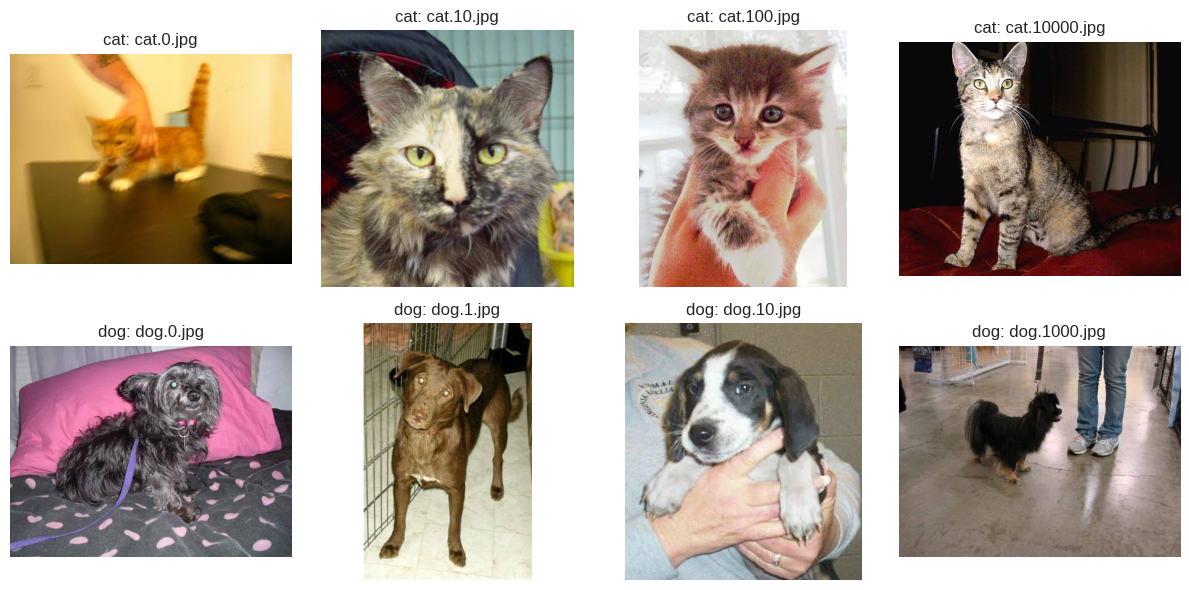

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image

# 나눔고딕 폰트 설정 (Colab 한글 깨짐 방지)
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    pass

def show_examples(split_name='train', n=4):
    fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))
    for row, class_name in enumerate(['cat', 'dog']):
        paths = sorted(
            (SPLIT_DIR / split_name / class_name).glob('*.jpg')
        )[:n]
        for ax, path in zip(axes[row], paths):
            ax.imshow(Image.open(path).convert('RGB'))
            ax.set_title(f'{class_name}: {path.name}')
            ax.axis('off')
    plt.tight_layout()
    plt.show()

show_examples('train', n=4)


classes: ['cat', 'dog']
class_to_idx: {'cat': 0, 'dog': 1}


/tmp/ipykernel_1576/2686798673.py:90: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1576/2686798673.py:90: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1576/2686798673.py:90: UserWarning: Glyph 51008 (\N{HANGUL SYLLABLE EUN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1576/2686798673.py:90: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1576/2686798673.py:90: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1576/2686798673.py:90: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1576/2686798673.py:90: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) Libe

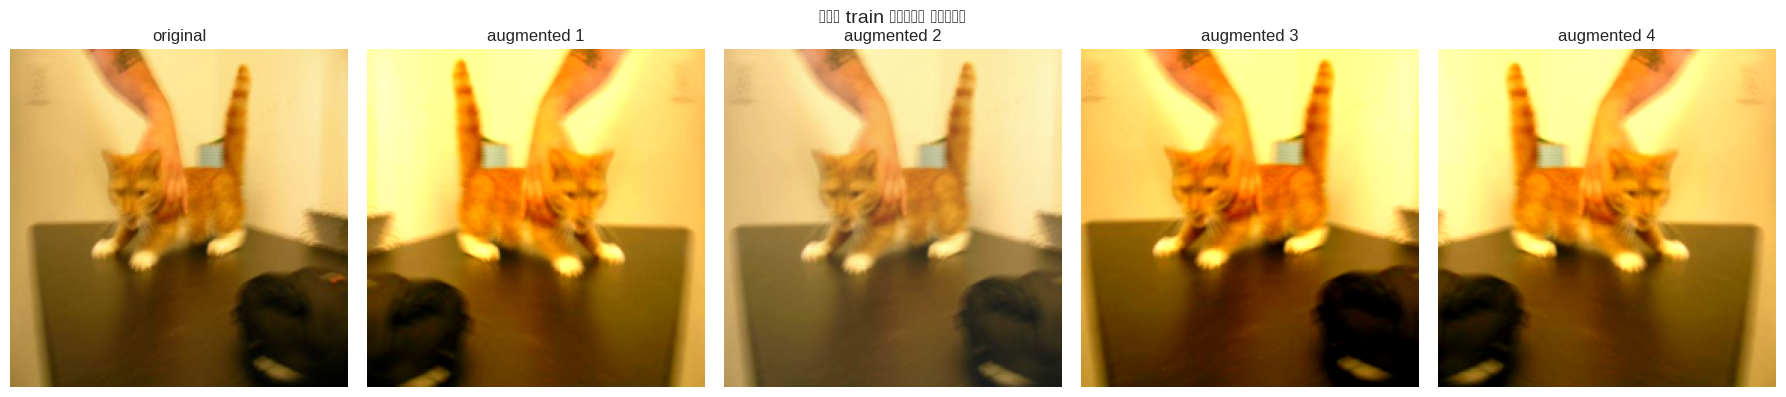

In [ ]:
# ImageNet 데이터셋의 평균/표준편차 — 사전학습 모델과 동일한 정규화를 적용합니다
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

# 기본 transform: 크기 변환 + 정규화만 적용
train_transform_base = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# 증강 transform: 학습 데이터에만 적용하는 다양한 변형
train_transform_aug = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# 평가 transform: val/test에는 증강 없이 동일한 전처리만 적용
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds_base = datasets.ImageFolder(
    SPLIT_DIR / 'train', transform=train_transform_base
)
train_ds_aug = datasets.ImageFolder(
    SPLIT_DIR / 'train', transform=train_transform_aug
)
val_ds = datasets.ImageFolder(
    SPLIT_DIR / 'val', transform=eval_transform
)
test_ds = datasets.ImageFolder(
    SPLIT_DIR / 'test', transform=eval_transform
)

class_names = train_ds_base.classes
print('classes:', class_names)

# ImageFolder는 폴더 이름을 알파벳 순으로 정렬하여 인덱스를 부여합니다
# cat=0, dog=1 → 나중에 sigmoid >= 0.5이면 dog으로 예측한다는 뜻입니다
print('class_to_idx:', train_ds_base.class_to_idx)

train_loader_base = DataLoader(
    train_ds_base, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)
train_loader_aug = DataLoader(
    train_ds_aug, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)


def denormalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return torch.clamp(tensor.cpu() * std + mean, 0, 1)

sample_path = sorted((SPLIT_DIR / 'train' / 'cat').glob('*.jpg'))[0]
sample_img = Image.open(sample_path).convert('RGB')

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
axes[0].imshow(sample_img.resize((IMG_SIZE, IMG_SIZE)))
axes[0].set_title('original')
axes[0].axis('off')

for i in range(4):
    aug_tensor = train_transform_aug(sample_img)
    axes[i + 1].imshow(denormalize(aug_tensor).permute(1, 2, 0))
    axes[i + 1].set_title(f'augmented {i + 1}')
    axes[i + 1].axis('off')

plt.suptitle('증강은 train 데이터에만 적용합니다', fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
class SimpleCNN(nn.Module):
    """
    간단한 3-layer CNN.
    Conv2d(3→32→64→128) + AdaptiveAvgPool + Dropout + Linear(128→1)
    """
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 224→224
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                              # 224→112
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # 112→112
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                              # 112→56
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # 56→56
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                              # 56→28
            nn.AdaptiveAvgPool2d((1, 1))                  # 28→1
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),   # 과적합 방지를 위해 30% 뉴런을 랜덤하게 끔
            nn.Linear(128, 1)  # 이진 분류이므로 출력 1개
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [ ]:
def accuracy_from_logits(logits, labels):
    """sigmoid >= 0.5 기준으로 예측하고 정확도를 계산합니다."""
    preds = (torch.sigmoid(logits) >= 0.5).long().view(-1)
    return (preds == labels.long()).sum().item()


def run_epoch(model, loader, criterion, optimizer=None):
    """1 에폭을 실행합니다. optimizer가 None이면 평가 모드입니다."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    running_corrects = 0
    total = 0

    # 예측 결과를 함께 수집합니다
    all_preds = []
    all_labels = []

    for inputs, labels in loader:
        inputs = inputs.to(device)
        # BCEWithLogitsLoss는 타겟을 float 형태의 (N, 1)로 기대합니다
        labels_bce = labels.float().unsqueeze(1).to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            outputs = model(inputs)
            loss = criterion(outputs, labels_bce)
            if is_train:
                loss.backward()
                optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += accuracy_from_logits(
            outputs, labels_bce.view(-1)
        )
        total += inputs.size(0)

        # 평가 모드일 때 예측 결과를 수집합니다
        if not is_train:
            preds = (
                torch.sigmoid(outputs) >= 0.5
            ).long().view(-1).cpu().numpy()
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.numpy().tolist())

    result = (running_loss / total, running_corrects / total)
    if not is_train:
        return result, np.array(all_labels), np.array(all_preds)
    return result


def train_model(model, train_loader, val_loader, criterion, optimizer, epochs):
    """여러 에폭을 반복하며 best model을 저장합니다."""
    best_state = deepcopy(model.state_dict())
    best_val_acc = 0.0
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    for epoch in range(epochs):
        start = time.time()
        train_loss, train_acc = run_epoch(
            model, train_loader, criterion, optimizer=optimizer
        )
        (val_loss, val_acc), _, _ = run_epoch(
            model, val_loader, criterion, optimizer=None
        )

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = deepcopy(model.state_dict())

        print(
            f'Epoch {epoch + 1}/{epochs} | '
            f'train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, '
            f'val_loss={val_loss:.4f}, val_acc={val_acc:.4f}, '
            f'time={time.time() - start:.1f}s'
        )

    model.load_state_dict(best_state)
    return model, history


@torch.no_grad()
def evaluate_model(model, loader, criterion):
    """test 세트를 한 번 순회하여 loss, accuracy, 예측 결과를 모두 반환합니다."""
    model.eval()
    (loss, acc), all_labels, all_preds = run_epoch(
        model, loader, criterion, optimizer=None
    )
    return {'loss': loss, 'accuracy': acc}, all_labels, all_preds


def plot_history(history, title):
    """학습 곡선(loss/accuracy)을 시각화합니다."""
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history['train_loss'], marker='o', label='train')
    axes[0].plot(epochs, history['val_loss'], marker='o', label='val')
    axes[0].set_title(f'{title} - Loss')
    axes[0].set_xlabel('epoch')
    axes[0].legend()

    axes[1].plot(epochs, history['train_acc'], marker='o', label='train')
    axes[1].plot(epochs, history['val_acc'], marker='o', label='val')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].set_xlabel('epoch')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_confusion(y_true, y_pred, class_names, title):
    """혼동 행렬을 시각화합니다."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')
    ax.set_title(title)
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, cm[i, j],
                    ha='center', va='center', color='black')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


results = {}


Baseline CNN trainable params: 93,377
Epoch 1/5 | train_loss=0.6839, train_acc=0.5414, val_loss=0.6615, val_acc=0.6200, time=15.8s
Epoch 2/5 | train_loss=0.6570, train_acc=0.5886, val_loss=0.6503, val_acc=0.6067, time=8.6s
Epoch 3/5 | train_loss=0.6454, train_acc=0.6171, val_loss=0.6415, val_acc=0.5978, time=9.7s
Epoch 4/5 | train_loss=0.6455, train_acc=0.6067, val_loss=0.6414, val_acc=0.6356, time=9.7s
Epoch 5/5 | train_loss=0.6371, train_acc=0.6195, val_loss=0.6360, val_acc=0.6289, time=9.6s


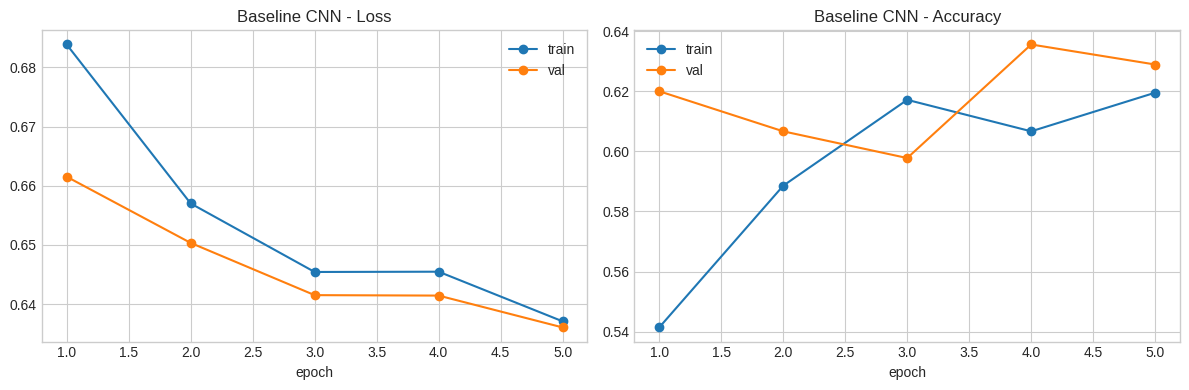

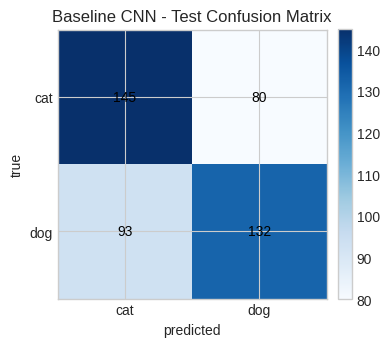

,precision,recall,f1-score,support
cat,0.609244,0.644444,0.626350,225.000000
dog,0.622642,0.586667,0.604119,225.000000
accuracy,0.615556,0.615556,0.615556,0.615556
macro avg,0.615943,0.615556,0.615234,450.000000
weighted avg,0.615943,0.615556,0.615234,450.000000


{'test_loss': 0.6479149670071072, 'test_accuracy': 0.6155555555555555, 'trainable_params': 93377}


In [ ]:
baseline_model = SimpleCNN().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(baseline_model.parameters(), lr=1e-3)

print(f'Baseline CNN trainable params: {count_trainable_params(baseline_model):,}')
baseline_model, baseline_history = train_model(
    baseline_model,
    train_loader_base,
    val_loader,
    criterion,
    optimizer,
    epochs=EPOCHS_SCRATCH
)

baseline_metrics, y_true_base, y_pred_base = evaluate_model(
    baseline_model, test_loader, criterion
)
plot_history(baseline_history, 'Baseline CNN')
plot_confusion(
    y_true_base, y_pred_base, class_names,
    'Baseline CNN - Test Confusion Matrix'
)

display(pd.DataFrame(
    classification_report(
        y_true_base, y_pred_base,
        target_names=class_names, output_dict=True
    )
).T)
results['Baseline CNN'] = {
    'test_loss': baseline_metrics['loss'],
    'test_accuracy': baseline_metrics['accuracy'],
    'trainable_params': count_trainable_params(baseline_model)
}
print(results['Baseline CNN'])


Augmented CNN trainable params: 93,377
Epoch 1/5 | train_loss=0.6802, train_acc=0.5781, val_loss=0.6663, val_acc=0.5933, time=14.0s
Epoch 2/5 | train_loss=0.6615, train_acc=0.5981, val_loss=0.6630, val_acc=0.5578, time=14.6s
Epoch 3/5 | train_loss=0.6483, train_acc=0.6110, val_loss=0.6651, val_acc=0.6000, time=17.4s
Epoch 4/5 | train_loss=0.6422, train_acc=0.6105, val_loss=0.6339, val_acc=0.6111, time=14.5s
Epoch 5/5 | train_loss=0.6364, train_acc=0.6210, val_loss=0.6359, val_acc=0.6000, time=14.3s


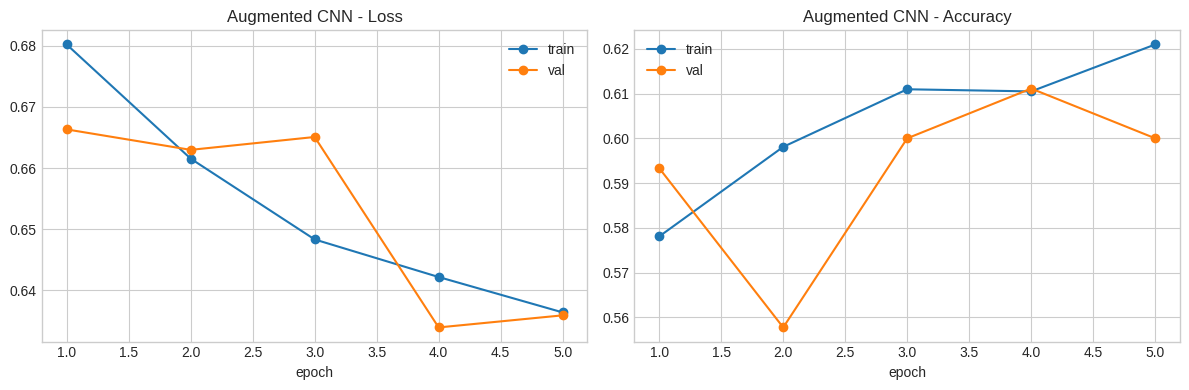

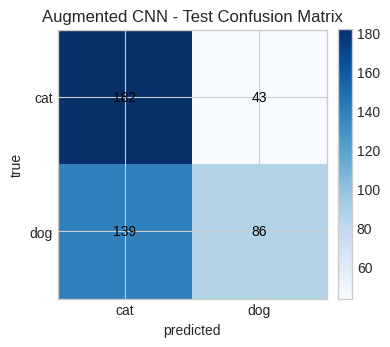

,precision,recall,f1-score,support
cat,0.566978,0.808889,0.666667,225.000000
dog,0.666667,0.382222,0.485876,225.000000
accuracy,0.595556,0.595556,0.595556,0.595556
macro avg,0.616822,0.595556,0.576271,450.000000
weighted avg,0.616822,0.595556,0.576271,450.000000


{'test_loss': 0.6399498648113675, 'test_accuracy': 0.5955555555555555, 'trainable_params': 93377}


In [ ]:
aug_model = SimpleCNN().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(aug_model.parameters(), lr=1e-3)

print(f'Augmented CNN trainable params: {count_trainable_params(aug_model):,}')
aug_model, aug_history = train_model(
    aug_model,
    train_loader_aug,
    val_loader,
    criterion,
    optimizer,
    epochs=EPOCHS_SCRATCH
)

aug_metrics, y_true_aug, y_pred_aug = evaluate_model(
    aug_model, test_loader, criterion
)
plot_history(aug_history, 'Augmented CNN')
plot_confusion(
    y_true_aug, y_pred_aug, class_names,
    'Augmented CNN - Test Confusion Matrix'
)

display(pd.DataFrame(
    classification_report(
        y_true_aug, y_pred_aug,
        target_names=class_names, output_dict=True
    )
).T)
results['Augmented CNN'] = {
    'test_loss': aug_metrics['loss'],
    'test_accuracy': aug_metrics['accuracy'],
    'trainable_params': count_trainable_params(aug_model)
}
print(results['Augmented CNN'])


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 124MB/s]


Transfer model trainable params: 513
Epoch 1/5 | train_loss=0.3557, train_acc=0.8814, val_loss=0.1888, val_acc=0.9533, time=9.6s
Epoch 2/5 | train_loss=0.1718, train_acc=0.9486, val_loss=0.1278, val_acc=0.9711, time=9.7s
Epoch 3/5 | train_loss=0.1373, train_acc=0.9562, val_loss=0.1066, val_acc=0.9756, time=9.9s
Epoch 4/5 | train_loss=0.1289, train_acc=0.9543, val_loss=0.0988, val_acc=0.9644, time=9.0s
Epoch 5/5 | train_loss=0.1187, train_acc=0.9629, val_loss=0.0880, val_acc=0.9756, time=9.4s


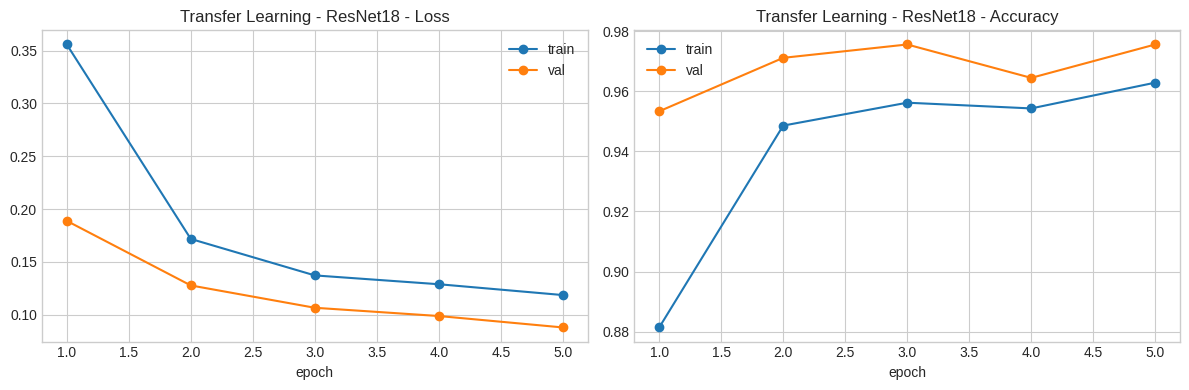

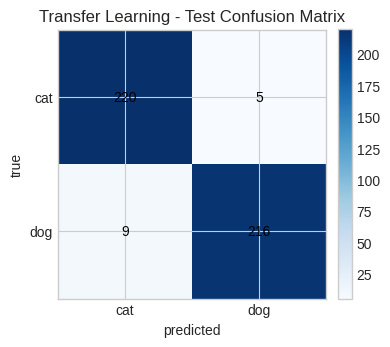

,precision,recall,f1-score,support
cat,0.960699,0.977778,0.969163,225.000000
dog,0.977376,0.960000,0.968610,225.000000
accuracy,0.968889,0.968889,0.968889,0.968889
macro avg,0.969037,0.968889,0.968886,450.000000
weighted avg,0.969037,0.968889,0.968886,450.000000


{'test_loss': 0.10145377333793375, 'test_accuracy': 0.9688888888888889, 'trainable_params': 513}


In [ ]:
# ResNet18_Weights.DEFAULT: 최신 torchvision API로 사전학습 가중치를 불러옵니다
weights = models.ResNet18_Weights.DEFAULT
transfer_model = models.resnet18(weights=weights)

# 모든 파라미터를 freeze — 사전학습된 특징을 그대로 사용합니다
for param in transfer_model.parameters():
    param.requires_grad = False

# 마지막 fc 레이어만 새로 교체 — 이 부분만 학습됩니다
transfer_model.fc = nn.Linear(transfer_model.fc.in_features, 1)
transfer_model = transfer_model.to(device)

criterion = nn.BCEWithLogitsLoss()
# fc 파라미터만 optimizer에 전달합니다
optimizer = optim.Adam(transfer_model.fc.parameters(), lr=1e-3)

print(f'Transfer model trainable params: {count_trainable_params(transfer_model):,}')
transfer_model, transfer_history = train_model(
    transfer_model,
    train_loader_base,
    val_loader,
    criterion,
    optimizer,
    epochs=EPOCHS_TRANSFER
)

transfer_metrics, y_true_transfer, y_pred_transfer = evaluate_model(
    transfer_model, test_loader, criterion
)
plot_history(transfer_history, 'Transfer Learning - ResNet18')
plot_confusion(
    y_true_transfer, y_pred_transfer, class_names,
    'Transfer Learning - Test Confusion Matrix'
)

display(pd.DataFrame(
    classification_report(
        y_true_transfer, y_pred_transfer,
        target_names=class_names, output_dict=True
    )
).T)
results['Transfer Learning (ResNet18)'] = {
    'test_loss': transfer_metrics['loss'],
    'test_accuracy': transfer_metrics['accuracy'],
    'trainable_params': count_trainable_params(transfer_model)
}
print(results['Transfer Learning (ResNet18)'])


Fine-tuning model trainable params: 8,394,241
Epoch 1/5 | train_loss=0.1332, train_acc=0.9500, val_loss=0.0510, val_acc=0.9822, time=14.7s
Epoch 2/5 | train_loss=0.0416, train_acc=0.9862, val_loss=0.0406, val_acc=0.9867, time=14.2s
Epoch 3/5 | train_loss=0.0248, train_acc=0.9929, val_loss=0.0627, val_acc=0.9756, time=14.2s
Epoch 4/5 | train_loss=0.0173, train_acc=0.9924, val_loss=0.0749, val_acc=0.9778, time=14.4s
Epoch 5/5 | train_loss=0.0132, train_acc=0.9967, val_loss=0.1232, val_acc=0.9733, time=14.4s


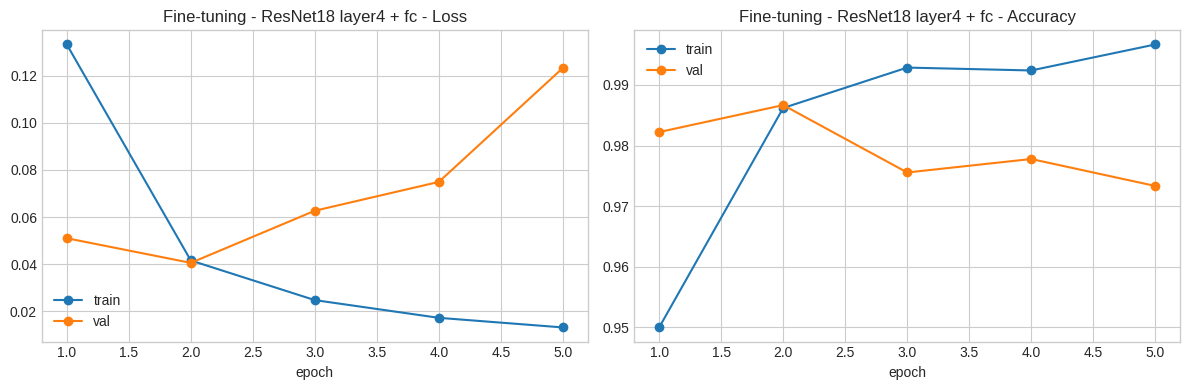

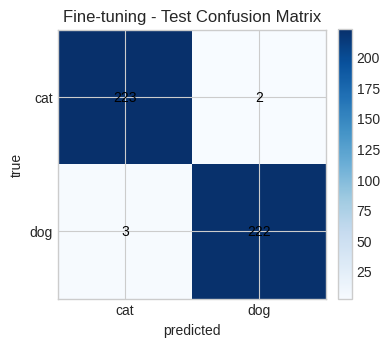

,precision,recall,f1-score,support
cat,0.986726,0.991111,0.988914,225.000000
dog,0.991071,0.986667,0.988864,225.000000
accuracy,0.988889,0.988889,0.988889,0.988889
macro avg,0.988899,0.988889,0.988889,450.000000
weighted avg,0.988899,0.988889,0.988889,450.000000


{'test_loss': 0.03453323239460587, 'test_accuracy': 0.9888888888888889, 'trainable_params': 8394241}


In [ ]:
finetune_model = models.resnet18(weights=weights)
for param in finetune_model.parameters():
    param.requires_grad = False

# layer4만 학습 가능하게 풀기
for param in finetune_model.layer4.parameters():
    param.requires_grad = True

finetune_model.fc = nn.Linear(finetune_model.fc.in_features, 1)
finetune_model = finetune_model.to(device)

criterion = nn.BCEWithLogitsLoss()
# 차등 학습률: 사전학습된 layer4는 낮게, 새 fc는 높게
optimizer = optim.Adam([
    {'params': finetune_model.layer4.parameters(), 'lr': 1e-4},
    {'params': finetune_model.fc.parameters(), 'lr': 1e-3}
], weight_decay=1e-4)

print(f'Fine-tuning model trainable params: {count_trainable_params(finetune_model):,}')
finetune_model, finetune_history = train_model(
    finetune_model,
    train_loader_aug,
    val_loader,
    criterion,
    optimizer,
    epochs=EPOCHS_TRANSFER
)

finetune_metrics, y_true_finetune, y_pred_finetune = evaluate_model(
    finetune_model, test_loader, criterion
)
plot_history(finetune_history, 'Fine-tuning - ResNet18 layer4 + fc')
plot_confusion(
    y_true_finetune, y_pred_finetune, class_names,
    'Fine-tuning - Test Confusion Matrix'
)

display(pd.DataFrame(
    classification_report(
        y_true_finetune, y_pred_finetune,
        target_names=class_names, output_dict=True
    )
).T)
results['Fine-tuning (ResNet18 layer4+fc)'] = {
    'test_loss': finetune_metrics['loss'],
    'test_accuracy': finetune_metrics['accuracy'],
    'trainable_params': count_trainable_params(finetune_model)
}
print(results['Fine-tuning (ResNet18 layer4+fc)'])


,test_loss,test_accuracy,trainable_params,test_accuracy_pct
Fine-tuning (ResNet18 layer4+fc),0.034533,0.988889,8394241,98.89
Transfer Learning (ResNet18),0.101454,0.968889,513,96.89
Baseline CNN,0.647915,0.615556,93377,61.56
Augmented CNN,0.639950,0.595556,93377,59.56


/tmp/ipykernel_1576/1185110569.py:16: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1576/1185110569.py:16: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1576/1185110569.py:16: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1576/1185110569.py:16: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1576/1185110569.py:16: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylab

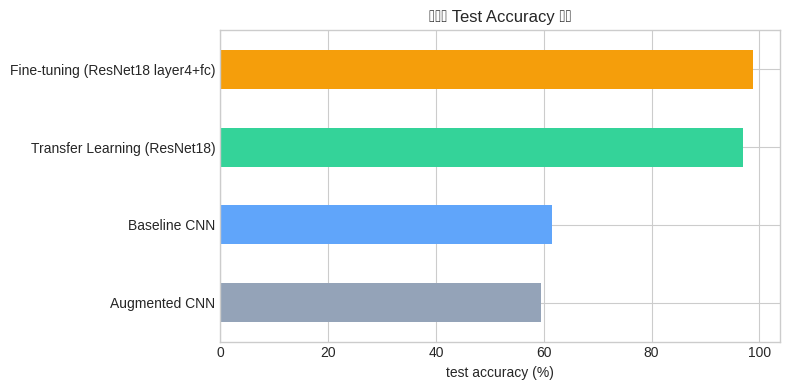

가장 높은 test accuracy를 기록한 모델: Fine-tuning (ResNet18 layer4+fc)
증강 효과: -2.00%p
전이학습 효과: +35.33%p
Fine-tuning 효과: +37.33%p


In [ ]:
comparison_df = pd.DataFrame(results).T
comparison_df['test_accuracy_pct'] = (
    comparison_df['test_accuracy'] * 100
).round(2)
comparison_df['trainable_params'] = (
    comparison_df['trainable_params'].astype(int)
)
display(comparison_df.sort_values('test_accuracy', ascending=False))

plot_df = comparison_df.sort_values('test_accuracy_pct')
colors = ['#94A3B8', '#60A5FA', '#34D399', '#F59E0B'][:len(plot_df)]
fig, ax = plt.subplots(figsize=(8, 4))
plot_df['test_accuracy_pct'].plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('test accuracy (%)')
ax.set_title('모델별 Test Accuracy 비교')
plt.tight_layout()
plt.show()

best_model_name = comparison_df['test_accuracy'].idxmax()
print(f'가장 높은 test accuracy를 기록한 모델: {best_model_name}')

if 'Baseline CNN' in results and 'Augmented CNN' in results:
    delta_aug = 100 * (
        results['Augmented CNN']['test_accuracy']
        - results['Baseline CNN']['test_accuracy']
    )
    print(f'증강 효과: {delta_aug:+.2f}%p')

if 'Baseline CNN' in results and 'Transfer Learning (ResNet18)' in results:
    delta_transfer = 100 * (
        results['Transfer Learning (ResNet18)']['test_accuracy']
        - results['Baseline CNN']['test_accuracy']
    )
    print(f'전이학습 효과: {delta_transfer:+.2f}%p')

if 'Baseline CNN' in results and 'Fine-tuning (ResNet18 layer4+fc)' in results:
    delta_finetune = 100 * (
        results['Fine-tuning (ResNet18 layer4+fc)']['test_accuracy']
        - results['Baseline CNN']['test_accuracy']
    )
    print(f'Fine-tuning 효과: {delta_finetune:+.2f}%p')


/tmp/ipykernel_1576/3936007655.py:56: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1576/3936007655.py:56: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1576/3936007655.py:56: UserWarning: Glyph 47448 (\N{HANGUL SYLLABLE RYU}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1576/3936007655.py:56: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1576/3936007655.py:56: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabt

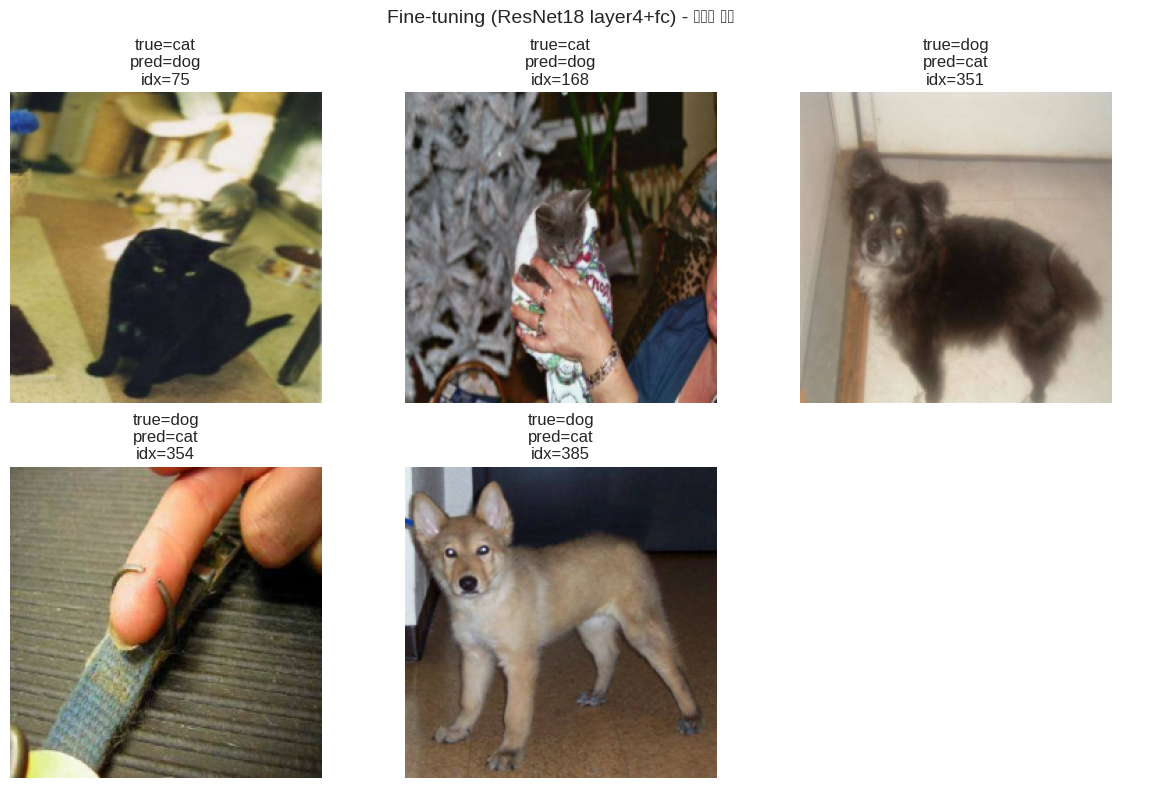

In [ ]:
def collect_misclassified_samples(
    model, dataset, class_names, max_items=9
):
    """
    오분류 샘플을 수집합니다.
    DataLoader 대신 개별 접근하는 이유: 오분류 이미지의 원본을
    인덱스와 함께 보존하기 위해서입니다.
    """
    model.eval()
    samples = []
    for idx in range(len(dataset)):
        image, label = dataset[idx]
        with torch.no_grad():
            logit = model(image.unsqueeze(0).to(device))
            pred = int((torch.sigmoid(logit).item()) >= 0.5)
        if pred != int(label):
            samples.append({
                'image': image,
                'true_label': class_names[int(label)],
                'pred_label': class_names[pred],
                'index': idx
            })
        if len(samples) >= max_items:
            break
    return samples


def show_misclassified_images(
    model, dataset, class_names, title, max_items=9
):
    samples = collect_misclassified_samples(
        model, dataset, class_names, max_items=max_items
    )
    if not samples:
        print('오분류 샘플이 없습니다.')
        return

    cols = 3
    rows = (len(samples) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, sample in zip(axes, samples):
        ax.imshow(denormalize(sample['image']).permute(1, 2, 0))
        ax.set_title(
            f"true={sample['true_label']}\n"
            f"pred={sample['pred_label']}\n"
            f"idx={sample['index']}"
        )
        ax.axis('off')

    for ax in axes[len(samples):]:
        ax.axis('off')

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


model_registry = {
    'Baseline CNN': baseline_model,
    'Augmented CNN': aug_model,
    'Transfer Learning (ResNet18)': transfer_model
}
if 'finetune_model' in globals():
    model_registry['Fine-tuning (ResNet18 layer4+fc)'] = finetune_model

selected_model_name = (
    best_model_name
    if 'best_model_name' in globals()
    else 'Transfer Learning (ResNet18)'
)
selected_model = model_registry[selected_model_name]
show_misclassified_images(
    selected_model,
    test_ds,
    class_names,
    title=f'{selected_model_name} - 오분류 샘플',
    max_items=9
)


In [ ]:
import torch

# 가장 성능이 좋은 모델 선택
best_name = comparison_df['test_accuracy'].idxmax()
best_model_obj = model_registry[best_name]
print(f'저장할 모델: {best_name}')

# state_dict 저장 (모델 구조는 별도로 정의해야 로드 가능)
torch.save(best_model_obj.state_dict(), 'best_model.pt')
print(f'모델 저장 완료: best_model.pt ({os.path.getsize("best_model.pt") / 1e6:.1f} MB)')


저장할 모델: Fine-tuning (ResNet18 layer4+fc)
모델 저장 완료: best_model.pt (44.8 MB)
